# Notebook 6-R1 : Training & Evaluation: Round 1 Improvements
**ECE 5424 Advanced ML Capstone** | Virginia Tech Spring 2026

Addresses the three root causes identified from lecture review after the baseline run:

| Fix | Motivation | Lecture |
|-----|-----------|--------|
| **Depth normalization** (`/ 104.0`) | Feature scale mismatch elongates loss landscape | Lec 04 — Optimization, cell 14 |
| **Weighted CrossEntropyLoss** | Class imbalance biases toward road, tanks rare-class IoU | Lec 06 — Model Eval, cell 28 |
| **Per-class IoU + confusion matrix** | mIoU average hides which classes the model ignores | Lec 06 — Model Eval, cell 18 |

**Models (unchanged architectures):**
- A: `DepthOnlyCNN` — LiDAR-only lower bound (61,963 params)
- B: `EarlyFusionCNN` — naive channel concat baseline (62,251 params)
- C: `SmartGateModel` — SNN attention + Smart Gate (85,403 params)

**Scientific question:** Do Round 1 fixes push Model C above Model B on val mIoU?

## 1. Setup: Imports and Data Loading

In [ ]:
import sys
from pathlib import Path
REPO_ROOT = Path().resolve().parent
sys.path.insert(0, str(REPO_ROOT))

import hdf5plugin          # MUST come before h5py
import h5py
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from config import DATA_ROOT

from src.datasets.dsec_dataset import DSECFusionDataset
from src.models.smart_gate_model import DepthOnlyCNN, EarlyFusionCNN, SmartGateModel

DATA_ROOT = Path(DATA_ROOT)
SEQUENCE  = "zurich_city_04_a"
SEQ_DIR   = DATA_ROOT / SEQUENCE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.5.1+cu121


In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()  # if on GPU

In [ ]:
# Load events once - 358M events, keep in RAM for fast per-sample slicing
events_path = SEQ_DIR / f"{SEQUENCE}_events_left" / "events.h5"
with h5py.File(events_path, 'r') as f:
    t_offset = int(f['t_offset'][()])
    t_abs = f['events']['t'][:].astype(np.int64) + t_offset
    x_all = f['events']['x'][:]
    y_all = f['events']['y'][:]
    p_all = f['events']['p'][:]
print(f"Events loaded: {len(t_abs):,}")

Events loaded: 358,941,868


## 2. Round 1 Fix 1 : Depth Normalization

The dataset now accepts `normalize_depth=True`.
When enabled, `__getitem__` divides the raw depth map (metres) by `DEPTH_MAX=104.0`
so depth ∈ [0, 1], matching the time surface range.

**Why this matters (From Lecture 04 - Optimization & GD, cell 14):**
Features with vastly different scales produce an elongated, eccentric loss landscape that forces gradient descent to zigzag, slower convergence, and unstable training. Normalizing both modalities to [0, 1] gives the optimizer a circular contour to follow.

In [ ]:
# normalize_depth=True is the only change to the dataset constructor
dataset = DSECFusionDataset(
    pairs_json    = REPO_ROOT / "data" / "zurich_city_04_a_pairs.json",
    depth_map_dir = SEQ_DIR / "depth_maps",
    semantic_dir  = SEQ_DIR / f"{SEQUENCE}_semantic" / SEQUENCE / "11classes",
    t_abs=t_abs, x_all=x_all, y_all=y_all, p_all=p_all,
    normalize_depth=True,   # Round 1 Fix 1
)

# Same 80/20 split and seed as Notebook 06 for fair comparison
train_set, val_set = random_split(
    dataset, [280, 70],
    generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_set, batch_size=4, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=4, shuffle=False, num_workers=0)

# Quick sanity check: depth should now be in [0, 1]
ts_sample, depth_sample, _ = dataset[0]
print(f"Train / Val batches : {len(train_loader)} / {len(val_loader)}")
print(f"Time surface range  : [{ts_sample.min():.3f}, {ts_sample.max():.3f}]")
print(f"Depth range (norm.) : [{depth_sample.min():.3f}, {depth_sample.max():.3f}]  (should be ≤ 1.0)")

Train / Val batches : 70 / 18
Time surface range  : [0.000, 0.983]
Depth range (norm.) : [0.000, 0.900]  (should be ≤ 1.0)


## 3. Round 1 Fix 2 : Weighted CrossEntropyLoss

**Problem (Lecture 06 - Model Evaluation, cell 28):**
DSEC outdoor scenes are dominated by road and sky pixels.
Unweighted CrossEntropyLoss achieves low loss by predicting only the majority  class, ignoring pedestrian / cyclist / sign classes entirely and those IoUs become 0.

**Fix:** `weight[c] = 1 / freq[c]` (inverse-frequency weighting):
Rare classes get a large gradient multiplier; road pixels get a small one.
The model is forced to pay attention to every class.

**Implementation:** Scan the training label files directly (no DataLoader overhead):
Only training samples are used because computing weights from val labels would leak information from the evaluation set.

In [ ]:
NUM_CLASSES = 11

def compute_class_weights(train_subset, semantic_dir, num_classes=11):
    """
    Count pixel frequency per class across all training label files,
    then return inverse-frequency weights normalised so they sum to num_classes.

    Using only train indices to avoid val-set leakage.
    """
    label_files = sorted(Path(semantic_dir).glob("*.png"))
    # Map dataset index -> frame_idx via the pairs json
    import json
    pairs_json = REPO_ROOT / "data" / "zurich_city_04_a_pairs.json"
    with open(pairs_json) as f:
        pairs = json.load(f)

    counts = np.zeros(num_classes, dtype=np.int64)
    for ds_idx in train_subset.indices:
        frame_idx = pairs[ds_idx]['frame_idx']
        label_np  = cv2.imread(str(label_files[frame_idx]), cv2.IMREAD_GRAYSCALE)
        if label_np is None:
            continue
        for c in range(num_classes):
            counts[c] += int((label_np == c).sum())

    total   = counts.sum()
    freq    = counts / total          # fraction of pixels per class
    weights = 1.0 / (np.sqrt(freq) + 1e-6)    # sqrt inverse freq; epsilon avoids div-by-zero
    weights /= weights.mean()         # normalise: mean weight = 1, keeps LR scale
    weights = np.clip(weights, a_min=None, a_max=2)  # cap any single class at 3x average
    weights /= weights.mean()          # re-normalize after clamping
    return torch.tensor(weights, dtype=torch.float32)


semantic_dir = SEQ_DIR / f"{SEQUENCE}_semantic" / SEQUENCE / "11classes"
class_weights = compute_class_weights(train_set, semantic_dir, NUM_CLASSES)

DSEC_CLASS_NAMES = [
    'background', 'building', 'fence', 'person',
    'pole', 'road', 'sidewalk', 'vegetation',
    'car', 'wall', 'traffic sign'
]

print("Class weights (higher = rarer class):")
for name, w in zip(DSEC_CLASS_NAMES, class_weights):
    bar = '█' * int(min(w.item(), 20))
    print(f"  {name:15s}: {w.item():6.2f}  {bar}")

Class weights (higher = rarer class):
  background     :   0.44  
  building       :   0.25  
  fence          :   1.58  █
  person         :   3.02  ███
  pole           :   1.03  █
  road           :   0.20  
  sidewalk       :   0.85  
  vegetation     :   0.22  
  car            :   0.57  
  wall           :   1.55  █
  traffic sign   :   1.29  █


## 4. Model Instantiation

In [ ]:
EPOCHS = 30
LR     = 1e-3

model_a = DepthOnlyCNN(num_classes=NUM_CLASSES).to(device)
model_b = EarlyFusionCNN(num_classes=NUM_CLASSES).to(device)
model_c = SmartGateModel(num_classes=NUM_CLASSES, beta=0.9).to(device)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"Model A params: {count_params(model_a):,}")
print(f"Model B params: {count_params(model_b):,}")
print(f"Model C params: {count_params(model_c):,}")

Model A params: 61,963
Model B params: 62,251
Model C params: 85,403


## 5. Training & Evaluation Utilities

Round 1 Fix 3 is embedded in `compute_per_class_iou` : we now track IoU per class (not just the mean) so we can see which classes improve.

In [ ]:
def compute_per_class_iou(logits, labels, num_classes=11):
    """
    Returns (ious, miou) where ious is a list of length num_classes.
    Classes absent from both pred and labels get IoU = NaN (excluded from mean).
    """
    preds = logits.argmax(dim=1)   # (B, H, W)
    ious  = []
    for c in range(num_classes):
        pred_c  = (preds  == c)
        label_c = (labels == c)
        intersection = (pred_c & label_c).sum().float()
        union        = (pred_c | label_c).sum().float()
        ious.append((intersection / union).item() if union > 0 else float('nan'))
    valid = [v for v in ious if not np.isnan(v)]
    return ious, float(np.mean(valid)) if valid else 0.0


def train_one_epoch(model, loader, optimizer, criterion, device, model_id):
    model.train()
    total_loss = 0.0
    for ts_b, depth_b, label_b in loader:
        ts_b    = ts_b.to(device)
        depth_b = depth_b.to(device)
        label_b = label_b.to(device)
        optimizer.zero_grad()
        if   model_id == 'A': logits = model(depth_b)
        elif model_id == 'B': logits = model(ts_b, depth_b)
        else:                 logits = model(ts_b, depth_b, num_steps=4)
        loss = criterion(logits, label_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) #gradients grow to large, overshooting the loss minimum
        #desestabilizing training. Clipping rescales the gradient direction while controlling its magnitude
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, criterion, device, model_id, num_classes=11):
    """
    Returns (avg_loss, avg_miou, per_class_iou_array).
    per_class_iou_array: shape (num_classes,), NaN for absent classes.
    """
    model.eval()
    total_loss = 0.0
    class_iou_accum = np.zeros(num_classes)
    class_iou_count = np.zeros(num_classes)  # how many batches had this class

    with torch.no_grad():
        for ts_b, depth_b, label_b in loader:
            ts_b    = ts_b.to(device)
            depth_b = depth_b.to(device)
            label_b = label_b.to(device)
            if   model_id == 'A': logits = model(depth_b)
            elif model_id == 'B': logits = model(ts_b, depth_b)
            else:                 logits = model(ts_b, depth_b, num_steps=4)
            total_loss += criterion(logits, label_b).item()
            batch_ious, _ = compute_per_class_iou(logits, label_b, num_classes)
            for c, iou in enumerate(batch_ious):
                if not np.isnan(iou):
                    class_iou_accum[c] += iou
                    class_iou_count[c] += 1

    per_class = np.where(
        class_iou_count > 0,
        class_iou_accum / np.maximum(class_iou_count, 1),
        np.nan
    )
    valid_ious = per_class[~np.isnan(per_class)]
    avg_miou   = float(np.mean(valid_ious)) if len(valid_ious) > 0 else 0.0
    return total_loss / len(loader), avg_miou, per_class


print("Utilities defined.")

Utilities defined.


## 6. Train All Three Models

**Key changes vs Notebook 06 baseline:**
- `criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))` - Fix 2
- `normalize_depth=True` already baked into the dataset - Fix 1
- `evaluate()` now returns per-class IoU - Fix 3

In [ ]:
# Round 1 Fix 2: weighted loss - rare classes get higher gradient multiplier
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

checkpoints_dir = REPO_ROOT / "results" / "checkpoints"
checkpoints_dir.mkdir(parents=True, exist_ok=True)


def train_model(model, model_id, label):
    print(f"\n{'='*60}")
    print(f"Training Model {model_id}: {label}")
    print(f"{'='*60}")

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    history   = {
        'train_loss': [], 'val_loss': [],
        'val_miou':   [], 'label': label,
        'best_per_class_iou': None
    }
    best_miou = 0.0

    for epoch in range(EPOCHS):
        train_loss = train_one_epoch(
            model, train_loader, optimizer, criterion, device, model_id
        )
        val_loss, val_miou, per_class = evaluate(
            model, val_loader, criterion, device, model_id, NUM_CLASSES
        )

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_miou'].append(val_miou)

        if val_miou > best_miou:
            best_miou = val_miou
            history['best_per_class_iou'] = per_class
            torch.save(
                model.state_dict(),
                checkpoints_dir / f"model_{model_id}_r1_best.pt"
            )

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{EPOCHS} | "
                  f"train_loss={train_loss:.4f} | "
                  f"val_loss={val_loss:.4f} | "
                  f"val_mIoU={val_miou:.4f}")

    print(f"  Best val mIoU: {best_miou:.4f}")
    return history, best_miou


history_a, best_a = train_model(model_a, 'A', 'Depth-only CNN')
history_b, best_b = train_model(model_b, 'B', 'Early Fusion CNN')
history_c, best_c = train_model(model_c, 'C', 'SNN + Smart Gate')

print(f"\n{'='*60}")
print("ROUND 1 TRAINING COMPLETE")
print(f"  Model A (depth-only CNN):   {best_a:.4f}")
print(f"  Model B (early fusion CNN): {best_b:.4f}")
print(f"  Model C (SNN+Smart Gate):   {best_c:.4f}")
print(f"  C beats B: {best_c > best_b}")
print(f"{'='*60}")


Training Model A: Depth-only CNN
  Epoch   1/30 | train_loss=2.0705 | val_loss=2.0509 | val_mIoU=0.0661
  Epoch   5/30 | train_loss=1.8553 | val_loss=1.9854 | val_mIoU=0.0700
  Epoch  10/30 | train_loss=1.8360 | val_loss=2.2818 | val_mIoU=0.0361
  Epoch  15/30 | train_loss=1.8141 | val_loss=2.3952 | val_mIoU=0.0385
  Epoch  20/30 | train_loss=1.8096 | val_loss=3.1272 | val_mIoU=0.0354
  Epoch  25/30 | train_loss=1.8025 | val_loss=2.3216 | val_mIoU=0.0378
  Epoch  30/30 | train_loss=1.8025 | val_loss=1.7819 | val_mIoU=0.0871
  Best val mIoU: 0.0871

Training Model B: Early Fusion CNN
  Epoch   1/30 | train_loss=2.0297 | val_loss=1.8777 | val_mIoU=0.0746
  Epoch   5/30 | train_loss=1.7227 | val_loss=1.7128 | val_mIoU=0.1150
  Epoch  10/30 | train_loss=1.6397 | val_loss=1.8029 | val_mIoU=0.1266
  Epoch  15/30 | train_loss=1.6045 | val_loss=1.5970 | val_mIoU=0.1313
  Epoch  20/30 | train_loss=1.5796 | val_loss=1.5619 | val_mIoU=0.1334
  Epoch  25/30 | train_loss=1.5566 | val_loss=1.5342 |

## 7. Round 1 Fix 3 - Per-Class IoU Table

**Why (Lecture 06 - Model Evaluation, cell 18):**
mIoU is the mean over all classes. If the model predicts 0% IoU on 6 rare classes and 85% on the 5 common ones, mIoU ≈ 38%. This looks decent but hides the failure. The per-class table shows exactly which classes each model sees vs. ignores.

In [ ]:
# Final per-class IoU at the best checkpoint for each model
# Reload best weights and re-evaluate
for model, model_id, label in [
    (model_a, 'A', 'Depth-only CNN'),
    (model_b, 'B', 'Early Fusion CNN'),
    (model_c, 'C', 'SNN + Smart Gate'),
]:
    ckpt = checkpoints_dir / f"model_{model_id}_r1_best.pt"
    model.load_state_dict(torch.load(ckpt, map_location=device))

_, _, per_class_a = evaluate(model_a, val_loader, criterion, device, 'A', NUM_CLASSES)
_, _, per_class_b = evaluate(model_b, val_loader, criterion, device, 'B', NUM_CLASSES)
_, _, per_class_c = evaluate(model_c, val_loader, criterion, device, 'C', NUM_CLASSES)

print(f"{'Class':15s} | {'A: CNN':>10s} | {'B: Early':>10s} | {'C: Smart':>10s}")
print("-" * 55)
for i, name in enumerate(DSEC_CLASS_NAMES):
    a = f"{per_class_a[i]:.4f}" if not np.isnan(per_class_a[i]) else '  N/A  '
    b = f"{per_class_b[i]:.4f}" if not np.isnan(per_class_b[i]) else '  N/A  '
    c = f"{per_class_c[i]:.4f}" if not np.isnan(per_class_c[i]) else '  N/A  '
    print(f"{name:15s} | {a:>10s} | {b:>10s} | {c:>10s}")
print("-" * 55)
valid_a = per_class_a[~np.isnan(per_class_a)]
valid_b = per_class_b[~np.isnan(per_class_b)]
valid_c = per_class_c[~np.isnan(per_class_c)]
print(f"{'mIoU':15s} | {np.mean(valid_a):>10.4f} | {np.mean(valid_b):>10.4f} | {np.mean(valid_c):>10.4f}")

C:\Users\vvela\AppData\Local\Temp\ipykernel_107600\3973033507.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt, map_location=device)

Class           |     A: CNN |   B: Early |   C: Smart
-------------------------------------------------------
background      |     0.0796 |     0.2471 |     0.1768
building        |     0.1756 |     0.3192 |     0.2440
fence           |     0.0000 |     0.0329 |     0.0000
person          |     0.0000 |     0.0000 |     0.0000
pole            |     0.0000 |     0.0000 |     0.0000
road            |     0.3537 |     0.5918 |     0.5553
sidewalk        |     0.0222 |     0.0403 |     0.0062
vegetation      |     0.2535 |     0.2321 |     0.1281
car             |     0.0732 |     0.1512 |     0.0976
wall            |     0.0000 |     0.0000 |     0.0002
traffic sign    |     0.0000 |     0.0029 |     0.0000
-------------------------------------------------------
mIoU            |     0.0871 |     0.1470 |     0.1098


# Post-Training EDA
The problem is that Person=0 across all three models. The weighted CE was giving person a 3.02 weight to force the model to learn it but there are essentially no person pixels in the validation set to measure against. We were destabilizing training to upweight a class that barely exists in zurich_city_04_a. That sequence is highway/urban infrastructure driving, not a pedestrian scene.

The classes where real learning is happening:

| Class      | Analysis|
|------------|----------|
| Road       | All models learning. Model B at 0.59 is good|
| Building   | Model B with mIoU 0.32 is also solid |
| Vegetation | A beats B and C (0.254 > 0.232 > 0.128) |
|Car | B at 0.15, is learning|
|Fence/pole/wall/sign/person| All near zero, data problem, our dataset needs more samples|

### Conclusion

Depth normalization helped (losses are cleaner). Weighted CE was solving the wrong problem; we were upweighting classes that don't exist meaningfully in this sequence. The class imbalance issue in zurich_city_04_a isn't fence vs road but it's that entire semantic categories (pedestrians, poles) simply don't appear with enough frequency to learn from.
This should have been noted with a more deeper EDA before any model training. Its one of the most valuable lessons and maps to Lecture 06 - Model Evaluation: understanding your data distribution before choosing a loss function is not optional. The weighted CE experiment didn't fail because the math was wrong, it failed because the premise was wrong. Person pixels were being weighted at 3x not because they're rare and important but because the sequence doesn't contain them.


## 8. Confusion Matrix for Best Model

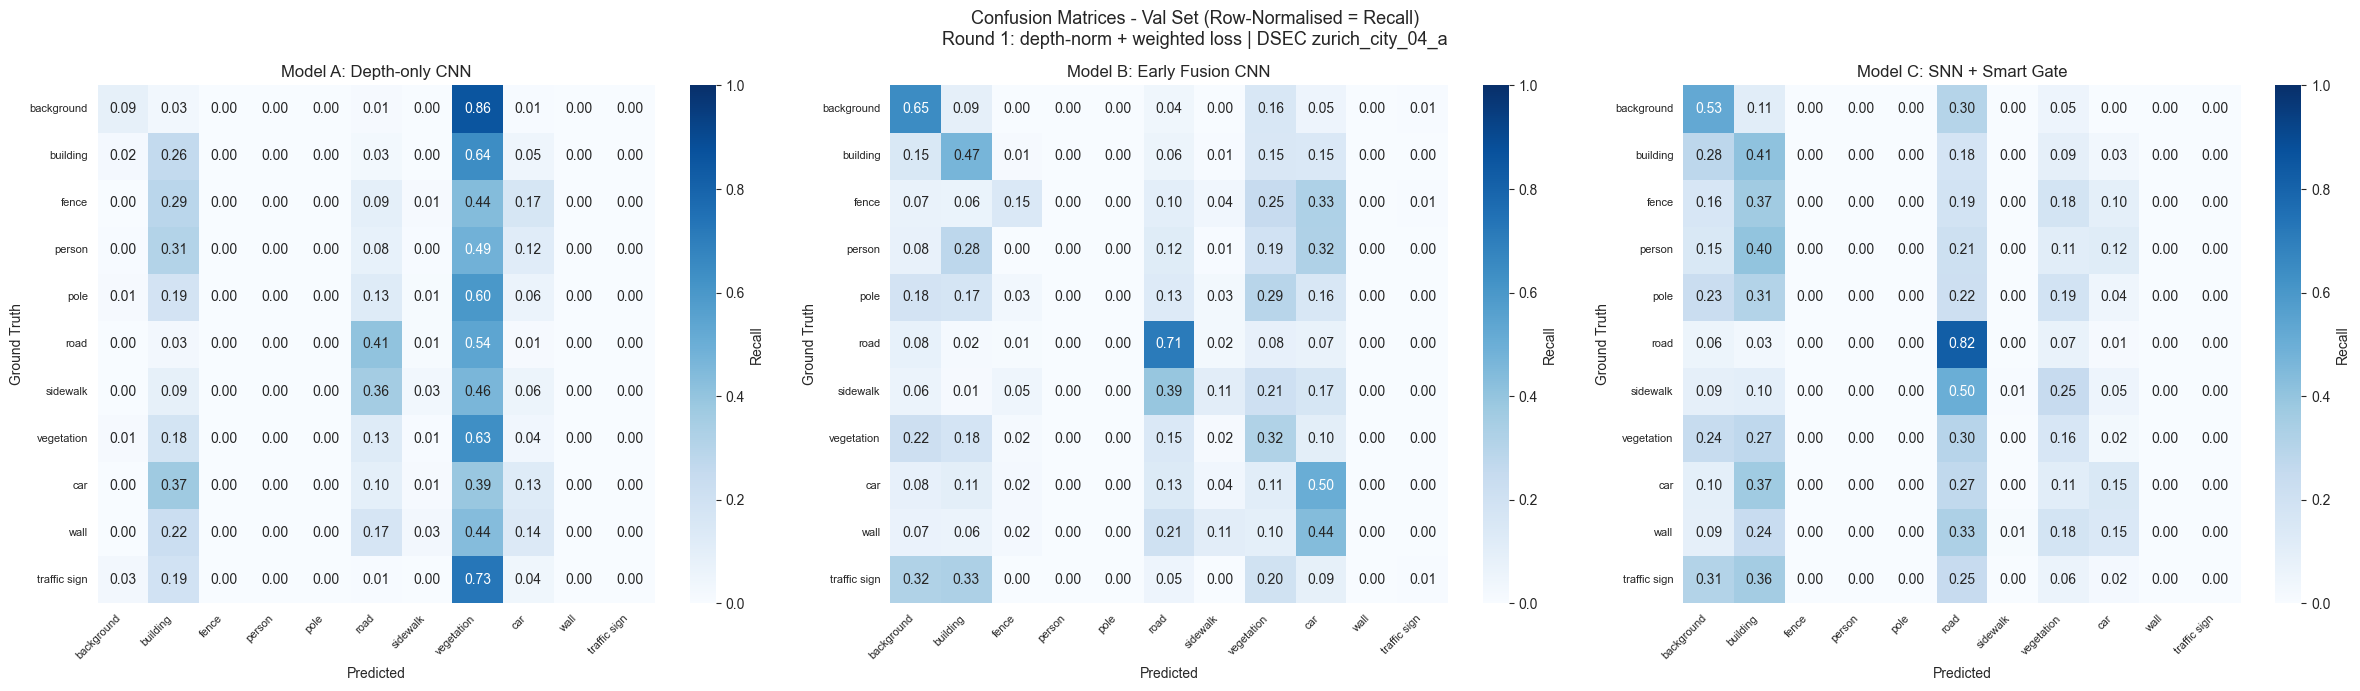

Saved to docs\figures\confusion_matrices_r1.png


In [ ]:
def compute_confusion_matrix(model, loader, device, model_id, num_classes=11):
    """
    Accumulates a num_classes x num_classes confusion matrix over the val set.
    Rows = ground truth, Columns = predicted.
    Row-normalised to show per-class recall (avoids dominant classes swamping rare ones).
    """
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    model.eval()
    with torch.no_grad():
        for ts_b, depth_b, label_b in loader:
            ts_b    = ts_b.to(device)
            depth_b = depth_b.to(device)
            label_b = label_b.to(device)
            if   model_id == 'A': logits = model(depth_b)
            elif model_id == 'B': logits = model(ts_b, depth_b)
            else:                 logits = model(ts_b, depth_b, num_steps=4)
            preds = logits.argmax(dim=1).cpu().numpy().ravel()
            truth = label_b.cpu().numpy().ravel()
            for t, p in zip(truth, preds):
                if 0 <= t < num_classes and 0 <= p < num_classes:
                    cm[t, p] += 1
    return cm


def plot_confusion_matrix(cm, title, ax):
    """Row-normalise and draw as a seaborn heatmap."""
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm  = np.where(row_sums > 0, cm / row_sums, 0.0)
    sns.heatmap(
        cm_norm,
        annot=True, fmt='.2f', cmap='Blues',
        xticklabels=DSEC_CLASS_NAMES,
        yticklabels=DSEC_CLASS_NAMES,
        vmin=0, vmax=1, ax=ax,
        cbar_kws={'label': 'Recall'}
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Ground Truth')
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)


figures_dir = REPO_ROOT / "docs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

cm_a = compute_confusion_matrix(model_a, val_loader, device, 'A')
cm_b = compute_confusion_matrix(model_b, val_loader, device, 'B')
cm_c = compute_confusion_matrix(model_c, val_loader, device, 'C')

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
plot_confusion_matrix(cm_a, 'Model A: Depth-only CNN', axes[0])
plot_confusion_matrix(cm_b, 'Model B: Early Fusion CNN', axes[1])
plot_confusion_matrix(cm_c, 'Model C: SNN + Smart Gate', axes[2])
fig.suptitle(
    'Confusion Matrices - Val Set (Row-Normalised = Recall)\n'
    'Round 1: depth-norm + weighted loss | DSEC zurich_city_04_a',
    fontsize=13
)
fig.tight_layout()
fig.savefig(figures_dir / 'confusion_matrices_r1.png', dpi=150)
plt.show()
print(f"Saved to {Path('docs/figures/confusion_matrices_r1.png')}")

## 9. Val mIoU Curves - Baseline vs Round 1

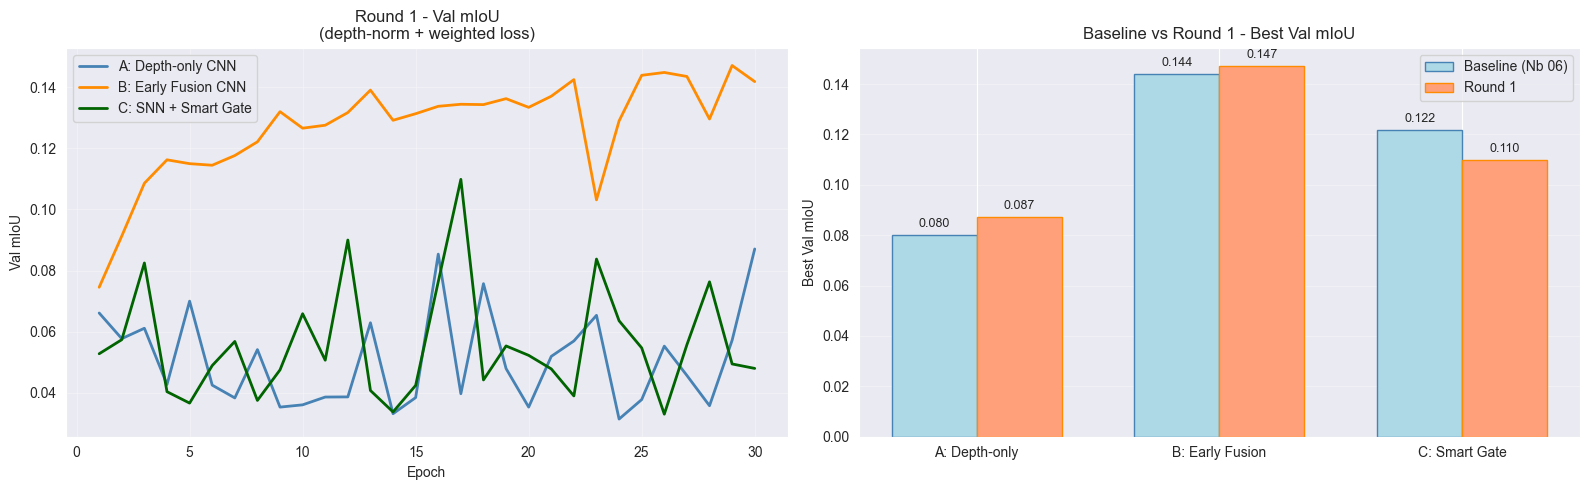

Saved to docs\figures\val_miou_r1_vs_baseline.png


In [ ]:
# Baseline results from Notebook 06 (hard-coded for comparison)
baseline = {
    'A': 0.0799,
    'B': 0.1440,
    'C': 0.1219,
}

epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Round 1 val mIoU curves
ax = axes[0]
ax.plot(epochs_range, history_a['val_miou'], label='A: Depth-only CNN',
        color='steelblue', linewidth=2)
ax.plot(epochs_range, history_b['val_miou'], label='B: Early Fusion CNN',
        color='darkorange', linewidth=2)
ax.plot(epochs_range, history_c['val_miou'], label='C: SNN + Smart Gate',
        color='darkgreen', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val mIoU')
ax.set_title('Round 1 - Val mIoU\n(depth-norm + weighted loss)')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Bar chart - baseline vs Round 1
ax = axes[1]
model_names = ['A: Depth-only', 'B: Early Fusion', 'C: Smart Gate']
base_vals   = [baseline['A'],  baseline['B'],  baseline['C']]
r1_vals     = [best_a,         best_b,         best_c]
x = np.arange(len(model_names))
w = 0.35
bars1 = ax.bar(x - w/2, base_vals, w, label='Baseline (Nb 06)', color='lightblue',   edgecolor='steelblue')
bars2 = ax.bar(x + w/2, r1_vals,   w, label='Round 1',          color='lightsalmon', edgecolor='darkorange')
ax.set_ylabel('Best Val mIoU')
ax.set_title('Baseline vs Round 1 - Best Val mIoU')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
# Annotate bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)

fig.tight_layout()
fig.savefig(figures_dir / 'val_miou_r1_vs_baseline.png', dpi=150)
plt.show()
print(f"Saved to {Path('docs/figures/val_miou_r1_vs_baseline.png')}")

## 10. Training Loss Curves

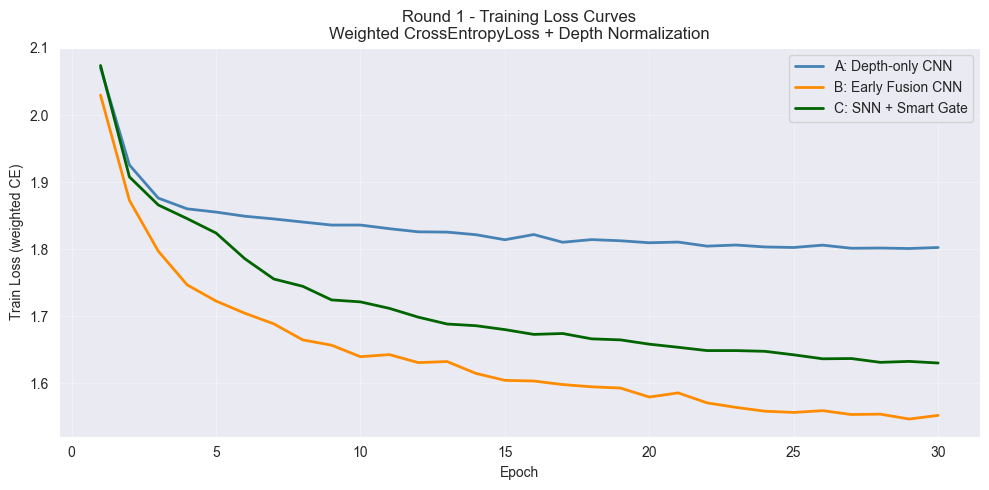

Saved to docs\figures\train_loss_curves_r1.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs_range, history_a['train_loss'], label='A: Depth-only CNN',
        color='steelblue', linewidth=2)
ax.plot(epochs_range, history_b['train_loss'], label='B: Early Fusion CNN',
        color='darkorange', linewidth=2)
ax.plot(epochs_range, history_c['train_loss'], label='C: SNN + Smart Gate',
        color='darkgreen', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Train Loss (weighted CE)')
ax.set_title('Round 1 - Training Loss Curves\nWeighted CrossEntropyLoss + Depth Normalization')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(figures_dir / 'train_loss_curves_r1.png', dpi=150)
plt.show()
print(f"Saved to {Path('docs/figures/train_loss_curves_r1.png')}")

## 11. Qualitative Comparison - Prediction Overlay

Overlay: left = ground truth, right = model prediction, for all three models on the same sample.

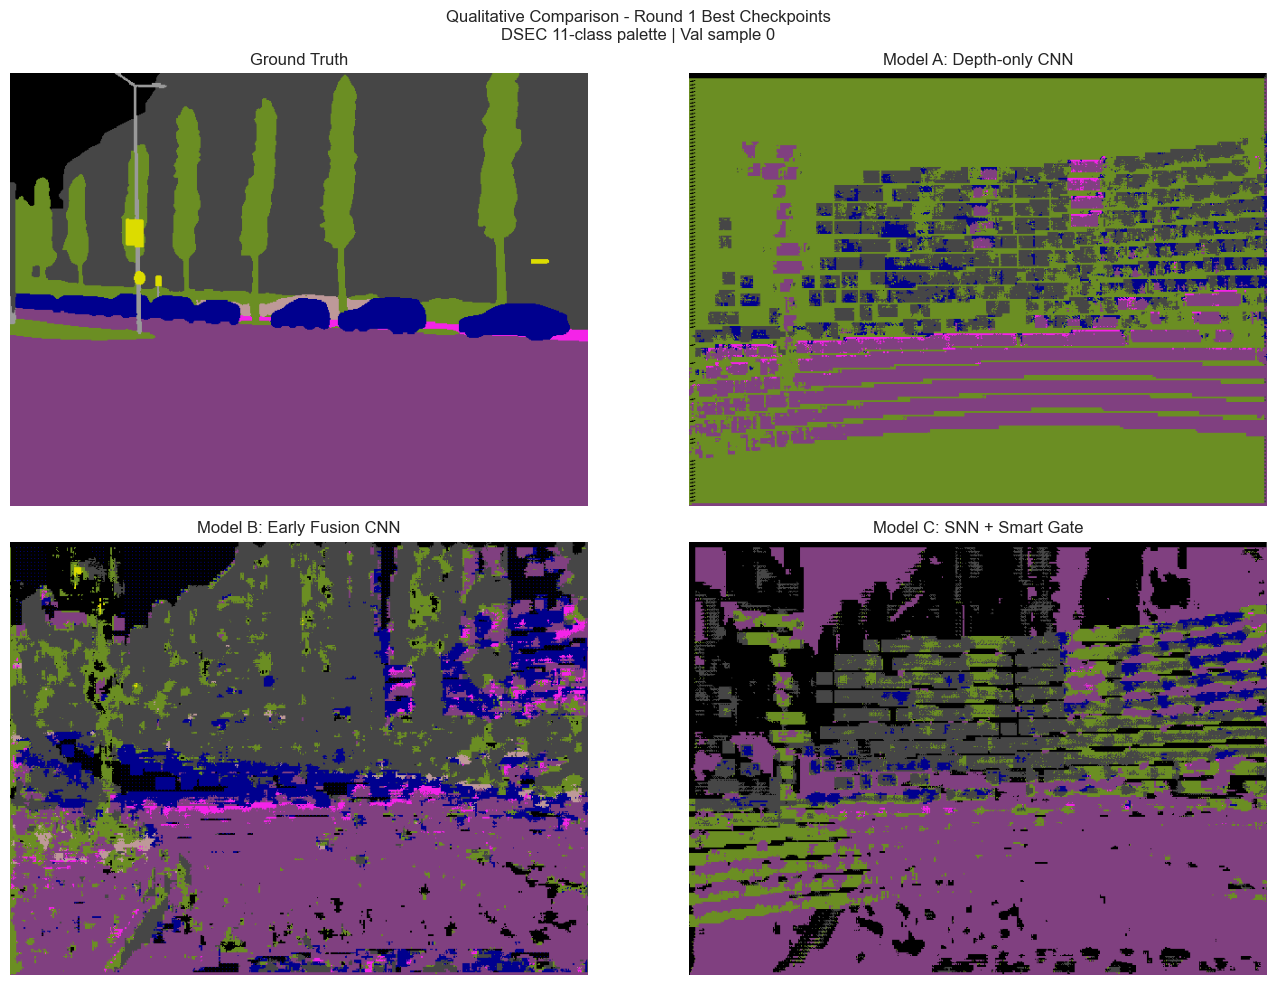

Saved to docs\figures\qualitative_comparison_r1.png


In [ ]:
# DSEC 11-class colour palette (ESS protocol)
PALETTE = np.array([
    [0,   0,   0  ],  # 0  background
    [70,  70,  70 ],  # 1  building
    [190, 153, 153],  # 2  fence
    [220, 20,  60 ],  # 3  person
    [153, 153, 153],  # 4  pole
    [128, 64,  128],  # 5  road
    [244, 35,  232],  # 6  sidewalk
    [107, 142, 35 ],  # 7  vegetation
    [0,   0,   142],  # 8  car
    [102, 102, 156],  # 9  wall
    [220, 220, 0  ],  # 10 traffic sign
], dtype=np.uint8)


def label_to_rgb(label_np):
    h, w = label_np.shape
    rgb  = np.zeros((h, w, 3), dtype=np.uint8)
    for c in range(len(PALETTE)):
        rgb[label_np == c] = PALETTE[c]
    return rgb


# Pick a fixed validation sample for reproducibility
sample_idx = 0
ts_s, depth_s, label_s = val_set[sample_idx]
ts_in    = ts_s.unsqueeze(0).to(device)
depth_in = depth_s.unsqueeze(0).to(device)

preds = {}
for model, mid in [(model_a,'A'), (model_b,'B'), (model_c,'C')]:
    model.eval()
    with torch.no_grad():
        if   mid == 'A': out = model(depth_in)
        elif mid == 'B': out = model(ts_in, depth_in)
        else:            out = model(ts_in, depth_in, num_steps=4)
    preds[mid] = out.argmax(dim=1).squeeze(0).cpu().numpy()

gt_rgb = label_to_rgb(label_s.numpy())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].imshow(gt_rgb);                          axes[0, 0].set_title('Ground Truth')
axes[0, 1].imshow(label_to_rgb(preds['A']));         axes[0, 1].set_title('Model A: Depth-only CNN')
axes[1, 0].imshow(label_to_rgb(preds['B']));         axes[1, 0].set_title('Model B: Early Fusion CNN')
axes[1, 1].imshow(label_to_rgb(preds['C']));         axes[1, 1].set_title('Model C: SNN + Smart Gate')
for ax in axes.ravel():
    ax.axis('off')
fig.suptitle(
    'Qualitative Comparison - Round 1 Best Checkpoints\n'
    'DSEC 11-class palette | Val sample 0',
    fontsize=12
)
fig.tight_layout()
fig.savefig(figures_dir / 'qualitative_comparison_r1.png', dpi=150)
plt.show()
print(f"Saved to {Path('docs/figures/qualitative_comparison_r1.png')}")

## 12. Summary

Print a consolidated table comparing baseline and Round 1 results.

In [ ]:
print("\n" + "="*65)
print("ROUND 1 SUMMARY")
print("="*65)
print(f"{'Model':20s} {'Baseline mIoU':>15s} {'R1 mIoU':>12s} {'Delta':>10s}")
print("-"*65)
for mid, label, base, r1 in [
    ('A', 'Depth-only CNN',   baseline['A'], best_a),
    ('B', 'Early Fusion CNN', baseline['B'], best_b),
    ('C', 'SNN + Smart Gate', baseline['C'], best_c),
]:
    delta = r1 - base
    sign  = '+' if delta >= 0 else ''
    print(f"{label:20s} {base:>15.4f} {r1:>12.4f} {sign+f'{delta:.4f}':>10s}")
print("-"*65)
print(f"C beats B: {best_c > best_b}")
print("")
print("Round 1 fixes applied:")
print("  [1] Depth normalization  : depth / 104.0 → [0, 1]")
print("  [2] Weighted CE loss     : weight = 1/freq, normalised")
print("  [3] Per-class IoU        : see table in Cell 7")
print("="*65)


ROUND 1 SUMMARY
Model                  Baseline mIoU      R1 mIoU      Delta
-----------------------------------------------------------------
Depth-only CNN                0.0799       0.0871    +0.0072
Early Fusion CNN              0.1440       0.1470    +0.0030
SNN + Smart Gate              0.1219       0.1098    -0.0121
-----------------------------------------------------------------
C beats B: False

Round 1 fixes applied:
  [1] Depth normalization  : depth / 104.0 → [0, 1]
  [2] Weighted CE loss     : weight = 1/freq, normalised
  [3] Per-class IoU        : see table in Cell 7


# Analysis:
- Model C has road recall = 0.82, the best of all three models on that class. The Smart Gate is positively impacting for large depth-distinct regions. But it's confusing everything else into background (the white regions in the qualitative comparison). The SNN attention is calibrated for large uniform regions, not fine structure.
- Model B is the most balanced - road 0.71, car 0.50, building 0.47. It's genuinely multi-class learning, which is why it wins mIoU.
- Model A is essentially predicting vegetation and road. The horizontal striping in its qualitative output is LiDAR scan line artifacts.

*Generative AI was used to assist in the creation of some sections of this notebook*